In [2]:
# All the imports

import numpy as np
np.set_printoptions(legacy='1.25')
import math
from skfem import MeshQuad, MeshTri, Basis, asm, condense
from skfem.element import ElementQuad1, ElementTriP1
from skfem.models.poisson import laplace
from skfem.helpers import dot, grad
from skfem import BilinearForm, LinearForm
from skfem.utils import solve
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot
from scipy.sparse.linalg import eigsh, ArpackNoConvergence
import pickle
from scipy.sparse.linalg import splu, LinearOperator, eigsh
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
from mpl_toolkits.mplot3d import Axes3D
import os

from eigenvector_convergence.eigenvector_helpers import (
    D_checkerboard, D_random, a_checkerboard, a_random, eigvecs_at_level,
    fix_sign, get_p_vals, mass, plot_bilinear_hat_solution,
)

# 2 Material Checkerboard Simulations

D_max: 1, level: 1, lambda1: 25.0, full_size: 9
D_max: 1, level: 2, lambda1: 21.773284010442474, full_size: 25
D_max: 1, level: 3, lambda1: 20.994161312494537, full_size: 81
D_max: 1, level: 4, lambda1: 20.80270735679788, full_size: 289
D_max: 1, level: 5, lambda1: 20.75506823506875, full_size: 1089
D_max: 1, level: 6, lambda1: 20.743172706514034, full_size: 4225
D_max: 1, level: 7, lambda1: 20.740199718588208, full_size: 16641
Refinement values:  [1, 2, 3, 4, 5, 6, 7]
|| \hat{u}_c - \hat{u}_f || : [0.1701237346678472, 0.03496819821983672, 0.008316467928984177, 0.002080274433629201, 0.0005461476233536533, 0.00015976426446077013, 5.324584477112182e-05]
< \hat{u}_c | \hat{u}_f> : [0.9855289574513321, 0.9993886125566291, 0.9999654181805931, 0.9999978362291405, 0.9999998508613867, 0.9999999872376899, 0.9999999985824402]
D_max: 3, level: 1, lambda1: 48.99999999999999, full_size: 9
D_max: 3, level: 2, lambda1: 42.01846569374839, full_size: 25
D_max: 3, level: 3, lambda1: 38.465686305068154, 

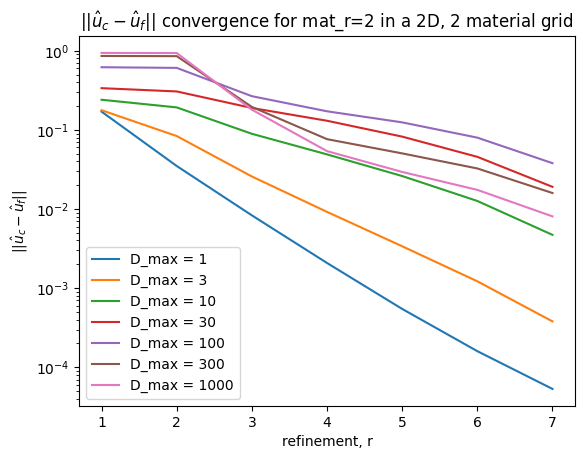

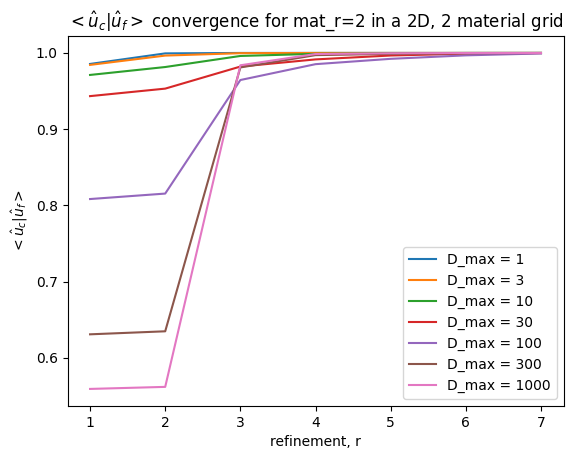

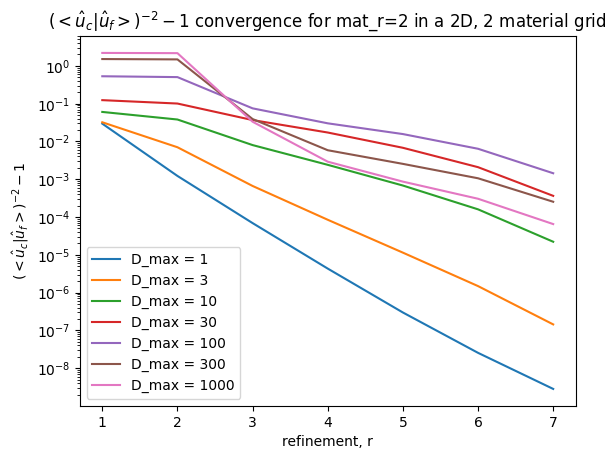

In [4]:
max_refinement = 7 # maximum refinement level for the coarse solutions
ref_refinement = 8 # refinement level for the reference solution
mat_r = 2 # refinement level of the 2-material checkerboard material grid
min_r = 1 # minimum refinement level for the coarse solutions
D_max_list = [1,3,10,30,100,300,1000]
coarse_sol_overlap_list = [] # list of coarse solution overlaps for each D_max
eigenvector_l2_error_list = [] # list of L2 errors between coarse and reference solutions for each D_max
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    # loop through the coarse refinement levels and compute the corresponding eigenvectors
    for r in range(min_r, max_refinement+1): 
        lambda1, u_full = eigvecs_at_level(mat_r=mat_r, r=r, D_max=D_max, D_min=1.0, do_plot=False, geometry="checkerboard")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(len(u_full)) 
        points_per_axis = int(np.sqrt(len(u_full)) + 0.1)
        Data_dict_dmax_1["free_size"].append((points_per_axis - 2) ** 2)
        Data_dict_dmax_1["u_full"].append(fix_sign(u_full))
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {len(u_full)}")

    # Use the finest eigenvector as the reference and interpolate every coarse
    # eigenvector onto its grid.  Eigenvectors have an arbitrary sign, so fix
    # that sign before normalizing and comparing their interior DOFs.
    lambda1, reference_solution = eigvecs_at_level(mat_r=mat_r, r=ref_refinement, D_max=D_max, D_min=1.0, do_plot=False, geometry="checkerboard")
    reference_solution = fix_sign(reference_solution)
    reference_points_per_axis = int(np.sqrt(len(reference_solution)) + 0.1)
    reference_grid = np.linspace(0.0, 1.0, reference_points_per_axis)
    reference_x, reference_y = np.meshgrid(reference_grid, reference_grid, indexing="ij")
    reference_points = np.column_stack((reference_x.ravel(), reference_y.ravel()))

    # get the interior points of the reference solution
    interior_mask = (
        (reference_points[:, 0] > 0.0) & (reference_points[:, 0] < 1.0)
        & (reference_points[:, 1] > 0.0) & (reference_points[:, 1] < 1.0)
    )
    reference_interior = reference_solution[interior_mask]
    reference_interior_normalized = reference_interior / np.linalg.norm(reference_interior)

    # store interpolated, normalized coarse solutions 
    interpolated_coarse_solutions = []
    interpolated_interior_coarse_normalized_solutions = []
    eigenvector_l2_errors = []
    for coarse_solution in Data_dict_dmax_1["u_full"]:
        coarse_solution = fix_sign(coarse_solution.copy())
        coarse_points_per_axis = int(np.sqrt(len(coarse_solution)) + 0.1)
        coarse_grid = np.linspace(0.0, 1.0, coarse_points_per_axis)
        coarse_values = coarse_solution.reshape(
            (coarse_points_per_axis, coarse_points_per_axis)
        )
        coarse_interpolator = RegularGridInterpolator(
            (coarse_grid, coarse_grid), coarse_values, method="linear"
        )
        interpolated_solution = coarse_interpolator(reference_points)
        interpolated_coarse_solutions.append(interpolated_solution)

        interpolated_interior = interpolated_solution[interior_mask]
        interpolated_interior_normalized = (
            interpolated_interior / np.linalg.norm(interpolated_interior)
        )
        interpolated_interior_coarse_normalized_solutions.append(interpolated_interior_normalized)

        eigenvector_l2_errors.append(
            np.linalg.norm(interpolated_interior_normalized - reference_interior_normalized)
        )

    # write the relevant data to the dictionary for the current D_max
    Data_dict_dmax_1["reference_solution"] = reference_solution
    Data_dict_dmax_1["reference_interior_normalized"] = reference_interior_normalized
    Data_dict_dmax_1["interpolated_coarse_solutions"] = interpolated_coarse_solutions
    Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"] = interpolated_interior_coarse_normalized_solutions
    Data_dict_dmax_1["chi"] = eigenvector_l2_errors

    # print and plot eigenvector results
    for r in range(min_r, max_refinement+1):
        flux_solution = Data_dict_dmax_1["u_full"][r-min_r].reshape((int(2**r+1), int(2**r+1))) # make the flux solution a square matrix
        grid_1D = np.linspace(0,1,int(2**r+1))

        flux_solution_interpolated = Data_dict_dmax_1["interpolated_coarse_solutions"][r-min_r].reshape((int(2**ref_refinement+1), int(2**ref_refinement+1))) # make the interpolated flux solution a square matrix
        grid_1D_interpolated = np.linspace(0,1,int(2**(ref_refinement)+1))

        # plot the original and interpolated coarse solutions
        #plot_bilinear_hat_solution(flux_solution, grid_1D, grid_1D, plot_type="heatmap") # plot the coarse-grid solution
        #plot_bilinear_hat_solution(flux_solution_interpolated, grid_1D_interpolated, grid_1D_interpolated, plot_type="heatmap") # plot the interpolated solution
        #print(f"Plotted refinement level {r}")

    # compute the overlap of the interpolated coarse solutions with the reference solution
    coarse_sol_overlaps = [np.dot(Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"][r], Data_dict_dmax_1["reference_interior_normalized"]) for r in range(0, max_refinement-min_r+1)]
    coarse_sol_overlap_list.append(coarse_sol_overlaps)
    eigenvector_l2_error_list.append(Data_dict_dmax_1["chi"])

    print("Refinement values: ", list(range(min_r, max_refinement+1)))
    #print(r'\hat{u}_c', Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"])
    #print(r'\hat{u}_f', Data_dict_dmax_1["reference_interior_normalized"])
    print(r'|| \hat{u}_c - \hat{u}_f || :', Data_dict_dmax_1["chi"])
    print(r'< \hat{u}_c | \hat{u}_f> :', coarse_sol_overlaps)

# plot the l2 norm of the error between the fine and coarse states
for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_refinement+1)), eigenvector_l2_error_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$|| \hat{u}_c - \hat{u}_f ||$')
plt.title(r'$|| \hat{u}_c - \hat{u}_f ||$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()

# plot the inner product of the fine and coarse states
for i in range(len(D_max_list)):
    plt.plot(list(range(min_r, max_refinement+1)), coarse_sol_overlap_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$< \hat{u}_c | \hat{u}_f>$')
plt.title(r'$< \hat{u}_c | \hat{u}_f>$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()

# Plot the failure probability, one minus the squared coarse-to-fine overlap.
for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_refinement+1)), 1 - np.square(coarse_sol_overlap_list[i]))
    plt.xlabel("refinement, r")
    plt.ylabel(r'$1 - |\langle \hat{u}_c | \hat{u}_f \rangle|^2$')
plt.title(r'Failure probability convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()




# Random Material Grid
Now every material region has a diffusion coefficient uniformly randomly sampled from the range $[D_{min}, D_{max}]$

D_max: 1, level: 1, lambda1: 25.0, full_size: 9
D_max: 1, level: 2, lambda1: 21.77328401044246, full_size: 25
D_max: 1, level: 3, lambda1: 20.994161312494537, full_size: 81
D_max: 1, level: 4, lambda1: 20.802707356797878, full_size: 289
D_max: 1, level: 5, lambda1: 20.755068235068748, full_size: 1089
D_max: 1, level: 6, lambda1: 20.743172706514027, full_size: 4225
D_max: 1, level: 7, lambda1: 20.7401997185882, full_size: 16641
Refinement values:  [1, 2, 3, 4, 5, 6, 7]
|| \hat{u}_c - \hat{u}_f || : [0.17012373466784728, 0.0349681982198367, 0.008316467928984163, 0.0020802744336292024, 0.0005461476233536508, 0.00015976426446076878, 5.3245844771120016e-05]
< \hat{u}_c | \hat{u}_f> : [0.9855289574513322, 0.9993886125566289, 0.9999654181805931, 0.9999978362291405, 0.9999998508613869, 0.9999999872376899, 0.9999999985824402]
D_max: 3, level: 1, lambda1: 48.99999999999999, full_size: 9
D_max: 3, level: 2, lambda1: 40.213607984825316, full_size: 25
D_max: 3, level: 3, lambda1: 38.20140959034213,

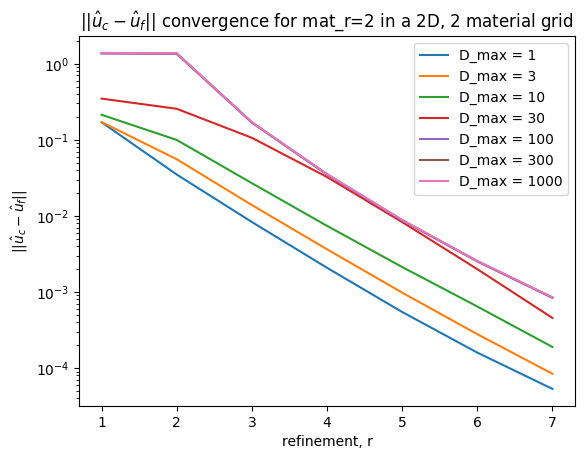

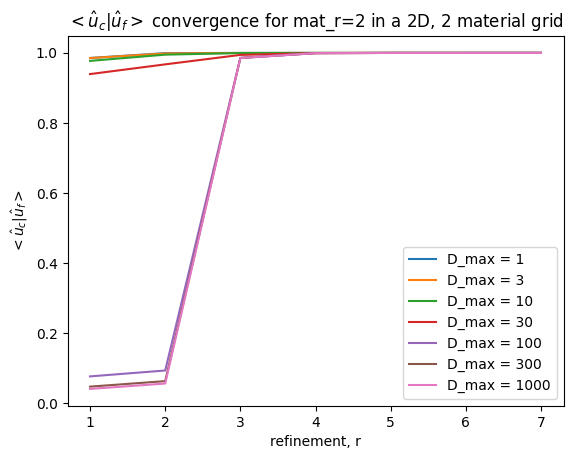

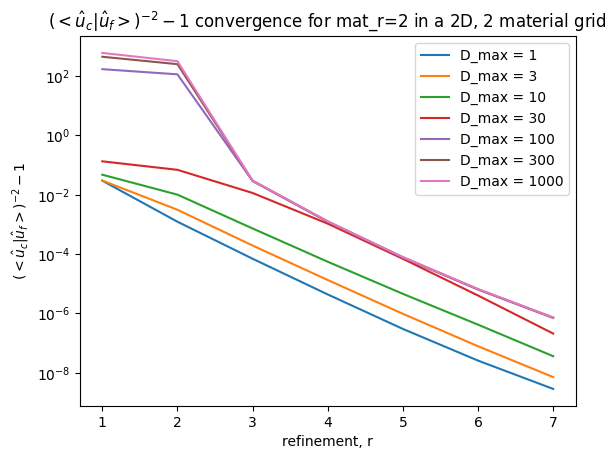

In [5]:
max_refinement = 7 # maximum refinement level for the coarse solutions
ref_refinement = 8 # refinement level for the reference solution
mat_r = 2 # refinement level of the 2-material checkerboard material grid
min_r = 1 # minimum refinement level for the coarse solutions
D_max_list = [1,3,10,30,100,300,1000]
coarse_sol_overlap_list = [] # list of coarse solution overlaps for each D_max
eigenvector_l2_error_list = [] # list of L2 errors between coarse and reference solutions for each D_max
for D_max in D_max_list:
    Data_dict_dmax_1 = {"levels": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    # loop through the coarse refinement levels and compute the corresponding eigenvectors
    for r in range(min_r, max_refinement+1): 
        lambda1, u_full = eigvecs_at_level(mat_r=mat_r, r=r, D_max=D_max, D_min=1.0, do_plot=False, geometry="random")
        Data_dict_dmax_1["levels"].append(r)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(len(u_full)) 
        points_per_axis = int(np.sqrt(len(u_full)) + 0.1)
        Data_dict_dmax_1["free_size"].append((points_per_axis - 2) ** 2)
        Data_dict_dmax_1["u_full"].append(fix_sign(u_full))
        print(f"D_max: {D_max}, level: {r}, lambda1: {lambda1}, full_size: {len(u_full)}")

    # Use the finest eigenvector as the reference and interpolate every coarse
    # eigenvector onto its grid.  Eigenvectors have an arbitrary sign, so fix
    # that sign before normalizing and comparing their interior DOFs.
    lambda1, reference_solution = eigvecs_at_level(mat_r=mat_r, r=ref_refinement, D_max=D_max, D_min=1.0, do_plot=False, geometry="random")
    reference_solution = fix_sign(reference_solution)
    reference_points_per_axis = int(np.sqrt(len(reference_solution)) + 0.1)
    reference_grid = np.linspace(0.0, 1.0, reference_points_per_axis)
    reference_x, reference_y = np.meshgrid(reference_grid, reference_grid, indexing="ij")
    reference_points = np.column_stack((reference_x.ravel(), reference_y.ravel()))

    # get the interior points of the reference solution
    interior_mask = (
        (reference_points[:, 0] > 0.0) & (reference_points[:, 0] < 1.0)
        & (reference_points[:, 1] > 0.0) & (reference_points[:, 1] < 1.0)
    )
    reference_interior = reference_solution[interior_mask]
    reference_interior_normalized = reference_interior / np.linalg.norm(reference_interior)

    # store interpolated, normalized coarse solutions 
    interpolated_coarse_solutions = []
    interpolated_interior_coarse_normalized_solutions = []
    eigenvector_l2_errors = []
    for coarse_solution in Data_dict_dmax_1["u_full"]:
        coarse_solution = fix_sign(coarse_solution.copy())
        coarse_points_per_axis = int(np.sqrt(len(coarse_solution)) + 0.1)
        coarse_grid = np.linspace(0.0, 1.0, coarse_points_per_axis)
        coarse_values = coarse_solution.reshape(
            (coarse_points_per_axis, coarse_points_per_axis)
        )
        coarse_interpolator = RegularGridInterpolator(
            (coarse_grid, coarse_grid), coarse_values, method="linear"
        )
        interpolated_solution = coarse_interpolator(reference_points)
        interpolated_coarse_solutions.append(interpolated_solution)

        interpolated_interior = interpolated_solution[interior_mask]
        interpolated_interior_normalized = (
            interpolated_interior / np.linalg.norm(interpolated_interior)
        )
        interpolated_interior_coarse_normalized_solutions.append(interpolated_interior_normalized)

        eigenvector_l2_errors.append(
            np.linalg.norm(interpolated_interior_normalized - reference_interior_normalized)
        )

    # write the relevant data to the dictionary for the current D_max
    Data_dict_dmax_1["reference_solution"] = reference_solution
    Data_dict_dmax_1["reference_interior_normalized"] = reference_interior_normalized
    Data_dict_dmax_1["interpolated_coarse_solutions"] = interpolated_coarse_solutions
    Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"] = interpolated_interior_coarse_normalized_solutions
    Data_dict_dmax_1["chi"] = eigenvector_l2_errors

    # print and plot eigenvector results
    for r in range(min_r, max_refinement+1):
        flux_solution = Data_dict_dmax_1["u_full"][r-min_r].reshape((int(2**r+1), int(2**r+1))) # make the flux solution a square matrix
        grid_1D = np.linspace(0,1,int(2**r+1))

        flux_solution_interpolated = Data_dict_dmax_1["interpolated_coarse_solutions"][r-min_r].reshape((int(2**ref_refinement+1), int(2**ref_refinement+1))) # make the interpolated flux solution a square matrix
        grid_1D_interpolated = np.linspace(0,1,int(2**(ref_refinement)+1))

        # plot the original and interpolated coarse solutions
        #plot_bilinear_hat_solution(flux_solution, grid_1D, grid_1D, plot_type="heatmap") # plot the coarse-grid solution
        #plot_bilinear_hat_solution(flux_solution_interpolated, grid_1D_interpolated, grid_1D_interpolated, plot_type="heatmap") # plot the interpolated solution
        #print(f"Plotted refinement level {r}")

    # compute the overlap of the interpolated coarse solutions with the reference solution
    coarse_sol_overlaps = [np.dot(Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"][r], Data_dict_dmax_1["reference_interior_normalized"]) for r in range(0, max_refinement-min_r+1)]
    coarse_sol_overlap_list.append(coarse_sol_overlaps)
    eigenvector_l2_error_list.append(Data_dict_dmax_1["chi"])

    print("Refinement values: ", list(range(min_r, max_refinement+1)))
    #print(r'\hat{u}_c', Data_dict_dmax_1["interpolated_interior_coarse_normalized_solutions"])
    #print(r'\hat{u}_f', Data_dict_dmax_1["reference_interior_normalized"])
    print(r'|| \hat{u}_c - \hat{u}_f || :', Data_dict_dmax_1["chi"])
    print(r'< \hat{u}_c | \hat{u}_f> :', coarse_sol_overlaps)

# plot the l2 norm of the error between the fine and coarse states
for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_refinement+1)), eigenvector_l2_error_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$|| \hat{u}_c - \hat{u}_f ||$')
plt.title(r'$|| \hat{u}_c - \hat{u}_f ||$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()

# plot the inner product of the fine and coarse states
for i in range(len(D_max_list)):
    plt.plot(list(range(min_r, max_refinement+1)), coarse_sol_overlap_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$< \hat{u}_c | \hat{u}_f>$')
plt.title(r'$< \hat{u}_c | \hat{u}_f>$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()

# Plot the failure probability, one minus the squared coarse-to-fine overlap.
for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_refinement+1)), 1 - np.square(coarse_sol_overlap_list[i]))
    plt.xlabel("refinement, r")
    plt.ylabel(r'$1 - |\langle \hat{u}_c | \hat{u}_f \rangle|^2$')
plt.title(r'Failure probability convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()


